# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [2]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [3]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [4]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [6]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [7]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [8]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [9]:
# 1. Diferencias entre LabelEncoder y OneHotEncoder

print("Codificación con LabelEncoder:")
print(data[['sex', 'sex_label']].head(10))

print("\nCodificación OneHotEncoder:")
print(data[['embarked', 'embarked_C', 'embarked_Q', 'embarked_S']].head(10))

Codificación con LabelEncoder:
      sex  sex_label
0    male          1
1  female          0
2  female          0
3  female          0
4    male          1
5    male          1
6    male          1
7    male          1
8  female          0
9  female          0

Codificación OneHotEncoder:
  embarked  embarked_C  embarked_Q  embarked_S
0        S       False       False        True
1        C        True       False       False
2        S       False       False        True
3        S       False       False        True
4        S       False       False        True
5        Q       False        True       False
6        S       False       False        True
7        S       False       False        True
8        S       False       False        True
9        C        True       False       False


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

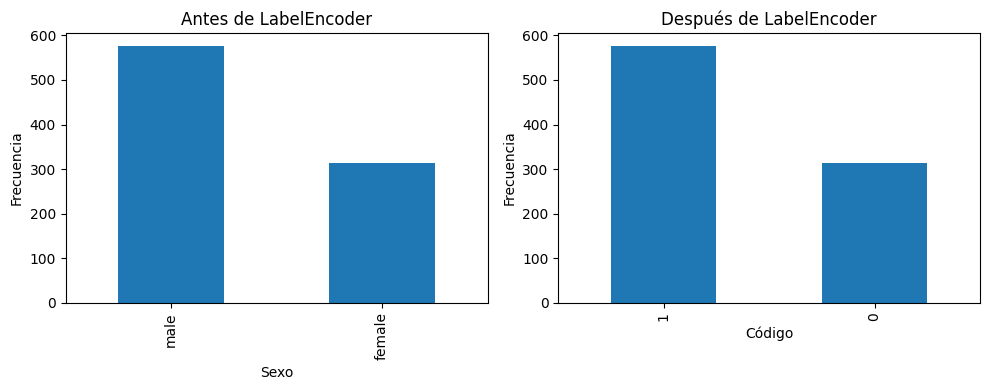

In [10]:
# 2. Comparar las frecuencias de 'sex' antes y después de LabelEncoder

import matplotlib.pyplot as plt

# Frecuencias antes de la codificación
frecuencias_sex = data['sex'].value_counts()

# Frecuencias después de la codificación
frecuencias_label = data['sex_label'].value_counts()

# Crear gráfica
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Antes de la codificación
frecuencias_sex.plot(kind='bar', ax=axes[0])
axes[0].set_title('Antes de LabelEncoder')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Frecuencia')

# Después de la codificación
frecuencias_label.plot(kind='bar', ax=axes[1])
axes[1].set_title('Después de LabelEncoder')
axes[1].set_xlabel('Código')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [11]:
# 3. Codificar la columna 'class' utilizando OneHotEncoder

onehot_encoder = OneHotEncoder(sparse_output=False)

class_encoded = onehot_encoder.fit_transform(data[['class']])

# Crear un DataFrame con las columnas codificadas
class_encoded_df = pd.DataFrame(
    class_encoded,
    columns=onehot_encoder.get_feature_names_out(['class'])
)

# Mostrar el resultado
print("Codificación de la columna 'class':")
print(class_encoded_df.head(10))

Codificación de la columna 'class':
   class_First  class_Second  class_Third
0          0.0           0.0          1.0
1          1.0           0.0          0.0
2          0.0           0.0          1.0
3          1.0           0.0          0.0
4          0.0           0.0          1.0
5          0.0           0.0          1.0
6          1.0           0.0          0.0
7          0.0           0.0          1.0
8          0.0           0.0          1.0
9          0.0           1.0          0.0


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [12]:
# 4. Codificación de variables categóricas para un modelo de aprendizaje automático

# LabelEncoder para 'sex'
sex_encoded = label_encoder.fit_transform(data['sex'])

# OneHotEncoder para 'class'
class_encoded = onehot_encoder.fit_transform(data[['class']])

# Mostrar los resultados
print("Variable 'sex' con LabelEncoder:")
print(sex_encoded[:10])

print("\nVariable 'class' con OneHotEncoder:")
print(class_encoded[:10])

Variable 'sex' con LabelEncoder:
[1 0 0 0 1 1 1 1 0 0]

Variable 'class' con OneHotEncoder:
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]]
